## Convert 2D Decoding to 1D

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
import spyglass as nd
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import xarray as xr
import logging
import os
import cupy as cp

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')

In [6]:
from spyglass.common import (Session, IntervalList,IntervalPositionInfo,
                             LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common.common_interval import _intersection

from spyglass.common.common_position import IntervalLinearizedPosition

import spyglass.spikesorting.v0 as ss
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SortInterval,
                                    SpikeSortingPreprocessingParameters,
                                    SpikeSortingRecording, 
                                    SpikeSorterParameters,
                                    SpikeSortingRecordingSelection,
                                    ArtifactDetectionParameters, ArtifactDetectionSelection,
                                    ArtifactRemovedIntervalList, ArtifactDetection,
                                      SpikeSortingSelection, SpikeSorting,
                                   CuratedSpikeSortingSelection,CuratedSpikeSorting,Curation)
from spyglass.decoding.v0.clusterless import (UnitMarks,
                                           UnitMarkParameters,UnitMarksIndicatorSelection,
                                          UnitMarksIndicator)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, IntervalPositionInfoSelection

from replay_trajectory_classification.environments import Environment
from spyglass.common.common_position import TrackGraph
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters
from spyglass.decoding.v0.visualization import make_single_environment_movie
from replay_trajectory_classification import ClusterlessClassifier

import pprint
# Here are the analysis tables specific to Shijie Gu
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear, ChangeofMindTheta,EpochPos,TrialChoice,Decode,DecodeIngredients,DecodeResults2D,MUA,DecodeIngredientsLikelihood
from spyglass.shijiegu.decodeHelpers import (thresholder_sort,runSessionNames,populateUnitMarks,intersectValidIntervals)
from spyglass.shijiegu.helpers import interpolate_to_new_time
from replay_trajectory_classification.environments import Environment


[2025-10-15 13:15:48,979][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
15-Oct-25 13:15:48 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [7]:
def get_2D_decoding_parameters():
    parameters = (ClusterlessClassifierParameters() & {'classifier_param_name': 'default_decoding_gpu_4armMaze'}).fetch1()
    parameters['classifier_params']['environments'] = Environment(
        infer_track_interior=True, fill_holes = True, dilate = True, bin_count_threshold = 4)
    return parameters
    
def convert_2D_to_1D_results(results, parameters_2D, environment2D):
    """convert_2D_to_1D_results"""
    
    parameters_1D = (ClusterlessClassifierParameters() & {'classifier_param_name': 'default_decoding_gpu_4armMaze'}).fetch1()
    classifier = ClusterlessClassifier(**parameters_2D['classifier_params'])
    
    track_name = parameters_1D['classifier_params']['environments'][0].environment_name
    
    track_graph = (TrackGraph() & {'track_graph_name': track_name}).get_networkx_track_graph()
    track_graph_params = (TrackGraph() & {'track_graph_name': track_name}).fetch1()
    
    environment1D = (
        Environment(
            track_graph=track_graph,
            edge_order=track_graph_params['linear_edge_order'],
            edge_spacing=track_graph_params['linear_edge_spacing'])
                .fit_place_grid())
    
    results1D = classifier.convert_2D_to_1D_results(
                results, environment2D, environment1D)
    
    return results1D
    
def return_place_bin_center2D():
    p = (ClusterlessClassifierParameters() & {'classifier_param_name': 'default_decoding_gpu_4armMaze'}).fetch1()
    track_name = p['classifier_params']['environments'][0].environment_name
    
    track_graph = (TrackGraph() & {'track_graph_name': track_name}).get_networkx_track_graph()
    track_graph_params = (TrackGraph() & {'track_graph_name': track_name}).fetch1()
    
    environment1D = (
        Environment(
            track_graph=track_graph,
            edge_order=track_graph_params['linear_edge_order'],
            edge_spacing=track_graph_params['linear_edge_spacing'])
                .fit_place_grid())
    place_bin_center1D = environment1D.place_bin_centers_
    place_bin_center2D = np.array(environment1D.place_bin_centers_nodes_df_[["x_position", "y_position"]])
    
    return place_bin_center1D, place_bin_center2D

In [8]:
nwb_copy_file_name_all = ['eliot20221021_.nwb']#'lewis20240118_.nwb','julio20230801_.nwb','julio20230802_.nwb','julio20230803_.nwb']
session_interval, position_interval = runSessionNames(nwb_copy_file_name_all[0])

In [13]:
DecodeResultsLinear() & {"nwb_file_name":nwb_copy_file_name_all[0]}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (1D)
eliot20221021_.nwb,02_Seq2Session1,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,all_maze,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,mobility_2Dheadspeed_above_6,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze_W20msO10ms,2Dheadspeed_above_4,=BLOB=
eliot20221021_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze_W40msO20ms,2Dheadspeed_above_4,=BLOB=
eliot20221021_.nwb,04_Seq2Session2,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221021_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=
eliot20221021_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=


In [10]:
nwb_copy_file_name = nwb_copy_file_name_all[0]
session_interval, position_interval = runSessionNames(nwb_copy_file_name)

In [ ]:
## start
for nwb_copy_file_name in nwb_copy_file_name_all:
    session_interval, position_interval = runSessionNames(nwb_copy_file_name)
    for e in range(len(session_interval)):
        session_name = session_interval[e]
        print(nwb_copy_file_name, session_name)
        entry = (DecodeResults2D & {
                           'nwb_file_name':nwb_copy_file_name,
                           "interval_list_name": session_name,
                           "classifier_param_name": "default_decoding_gpu_4armMaze",
                           "encoding_set":"2Dheadspeed_above_4",
                          })
        decode_path2d = entry.fetch1("posterior")
        decode_path1d = entry.fetch1("posterior_1d")
        environment2D_path = entry.fetch1("classifier")
        
        results = xr.open_zarr(decode_path2d, consolidated=False)
        parameters = get_2D_decoding_parameters()

        with open(environment2D_path, 'rb') as file:
            environment2D = pickle.load(file)
        
        results1D = convert_2D_to_1D_results(results, parameters, environment2D)
        results1D.to_zarr(decode_path1d, consolidated=False)

        print(f"Epoch {e} finished.")


lewis20240118_.nwb 02_Rev1Session1


[16:08:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
12-Oct-25 16:08:29 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:08:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
12-Oct-25 16:08:29 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:444: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be 

Epoch 0 finished.
lewis20240118_.nwb 04_Rev1Session2


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:444: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, n_elements in results2D.dims.items()
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:442: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  non_position_dims = [
[17:16:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
12

Epoch 1 finished.
lewis20240118_.nwb 06_Rev1Session3


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:444: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, n_elements in results2D.dims.items()
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:442: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  non_position_dims = [


Epoch 2 finished.
lewis20240118_.nwb 08_Rev1Session4


[17:49:40][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
12-Oct-25 17:49:40 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[17:49:40][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
12-Oct-25 17:49:40 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:444: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be 

In [26]:
decode_path1d

'/cumulus/shijie/recording_pilot/molly/decoding/molly20220417_.nwb_10_Seq2Session5_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result_2D1D.zarr'

In [56]:
nwb_copy_file_name

'klein20231106_.nwb'

### Plotting

In [93]:
nwb_copy_file_name = "lewis20240109_.nwb"
session_name = "04_Rev2Session2"

In [94]:
entry = DecodeIngredients & {'nwb_file_name':nwb_copy_file_name,
                             'interval_list_name':session_name}
    
# Get data
position_1d = pd.read_csv(entry.fetch1('position_1d')) #still need 1D position

In [95]:
key={'nwb_file_name':nwb_copy_file_name,'epoch':4}
print(ChangeofMindTheta & key)
log = ChangeofMindTheta().fetch1_dataframe(key)

session_name = (TrialChoice & key).fetch1('epoch_name')

print(f"Session {session_name}")

[2025-09-24 21:51:41,491][WARNING]: Skipped checksum for file with hash: 0d13cdf6-5436-9a97-68ea-0eb3849664c5, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XZOX9O55PQ.nwb
24-Sep-25 21:51:41 Skipped checksum for file with hash: 0d13cdf6-5436-9a97-68ea-0eb3849664c5, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XZOX9O55PQ.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240109_ 4         0.1            0              2              0            lewis20240109_
 (Total: 1)

Session 04_Rev2Session2


In [96]:
log[log.change_of_mind]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,theta_dev,long_theta,CoMMaxProportion,initial_choice,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
id,,,,,,,,,,,,,,,,,,,,,
11,1.704833e+09,1.0,1.704833e+09,2.0,2.0,True,0,False,0.552658,3.0,...,0.000000,0.552658,0.000000,1,1,2.0,2.0,4.0,1.0,1.0
13,1.704833e+09,1.0,1.704833e+09,3.0,2.0,True,0,False,0.578062,1.0,...,0.111066,0.000000,0.000000,2,2,3.0,3.0,1.0,4.0,4.0
14,1.704833e+09,1.0,1.704833e+09,1.0,2.0,True,0,False,0.134795,2.0,...,0.134795,0.000000,0.000000,1,1,1.0,1.0,2.0,3.0,3.0
28,1.704833e+09,1.0,1.704833e+09,3.0,1.0,True,0,False,0.106553,4.0,...,0.000000,0.000000,0.106553,1,1,3.0,3.0,4.0,2.0,2.0
39,1.704834e+09,1.0,1.704834e+09,3.0,2.0,True,0,False,0.607114,3.0,...,0.607114,0.000000,0.000000,2,1,3.0,3.0,1.0,1.0,4.0
41,1.704834e+09,1.0,1.704834e+09,4.0,1.0,True,0,False,1.000000,3.0,...,0.000000,1.000000,0.000000,2,1,4.0,4.0,2.0,1.0,1.0
43,1.704834e+09,1.0,1.704834e+09,3.0,1.0,True,0,False,0.334493,3.0,...,0.000000,0.000000,0.000000,2,1,3.0,3.0,4.0,2.0,2.0
44,1.704834e+09,1.0,1.704834e+09,4.0,2.0,True,0,False,0.647582,1.0,...,0.000000,0.000000,0.000000,1,1,4.0,4.0,3.0,3.0,2.0
45,1.704834e+09,1.0,1.704834e+09,3.0,2.0,True,0,False,0.548515,2.0,...,0.548515,0.000000,0.000000,1,1,3.0,3.0,1.0,4.0,4.0


In [97]:
# old 1D decoding
decoding_path=(DecodeResultsLinear & {'nwb_file_name': nwb_copy_file_name,
          'interval_list_name': session_name,
          "classifier_param_name": "default_decoding_gpu_4armMaze",
          "encoding_set":"2Dheadspeed_above_4"}).fetch1('posterior')
results1D_old = xr.open_dataset(decoding_path)

In [99]:
results1D

<xarray.Dataset> Size: 16GB
Dimensions:            (time: 1118616, state: 2, position: 301)
Coordinates:
  * time               (time) float64 9MB 1.705e+09 1.705e+09 ... 1.705e+09
  * state              (state) <U10 80B 'Continuous' 'Uniform'
  * position           (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
Data variables:
    acausal_posterior  (time, state, position) float64 5GB 0.0006681 ... 0.0682
    causal_posterior   (time, state, position) float64 5GB 0.02638 ... 0.0682
    likelihood         (time, state, position) float64 5GB 38.04 43.36 ... 945.7
Attributes:
    data_log_likelihood:  -904793.5

In [98]:
results1D_old

<xarray.Dataset> Size: 809MB
Dimensions:            (time: 111860, state: 2, position: 301)
Coordinates:
  * time               (time) float64 895kB 1.705e+09 1.705e+09 ... 1.705e+09
  * position           (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
  * state              (state) <U10 80B 'Continuous' 'Uniform'
Data variables:
    likelihood         (time, state, position) float32 269MB ...
    causal_posterior   (time, state, position) float32 269MB ...
    acausal_posterior  (time, state, position) float32 269MB ...
Attributes:
    data_log_likelihood:  -129455.16

In [100]:
trialInd = 24 #TO DO 63 has a problem
t0 = log.loc[trialInd,'timestamp_H'] + 4
t1 = log.loc[trialInd + 1,'timestamp_H']
if np.isnan(t0):
    t0 = t1-12

timestamps = np.array(position_1d.time)
frameToPlot = np.argwhere(np.logical_and(timestamps>=t0,timestamps<=t1)).ravel()
frame0 = frameToPlot[0]
frameLast = frameToPlot[-1]

In [109]:
frame0

303587

In [102]:
frameLast

316187

### Old 1D decoding

TypeError: No numeric data to plot.

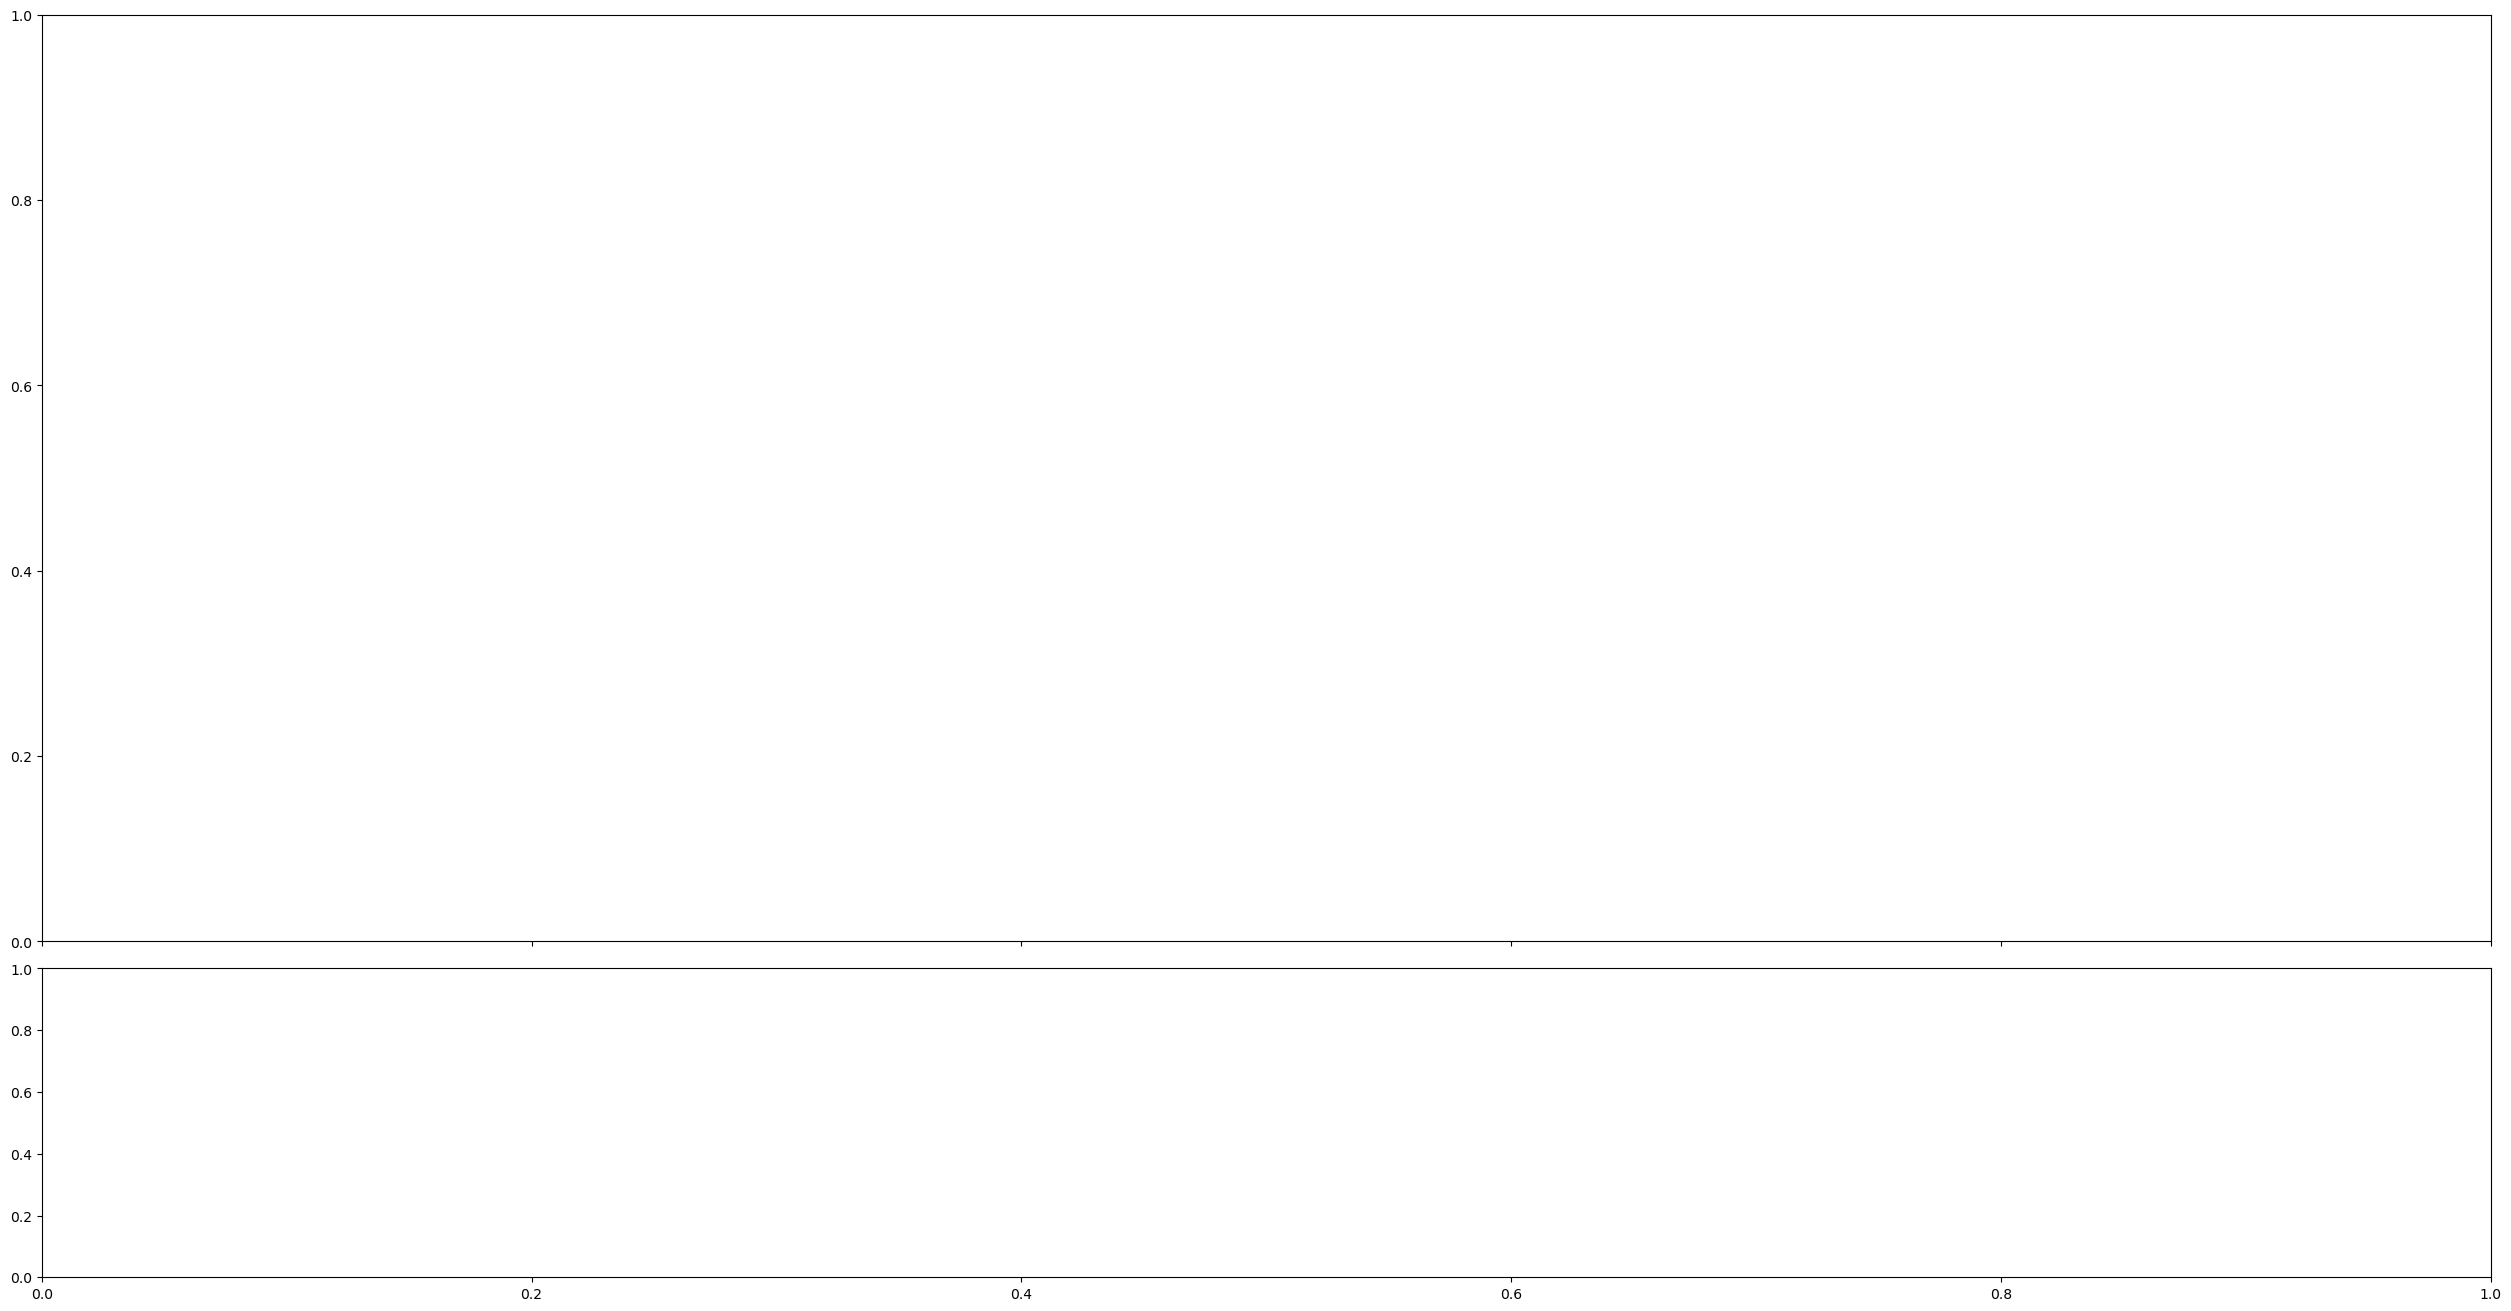

In [103]:
import matplotlib.pyplot as plt
for time_ind in range(frame0, frame0 + 1000 * 20, 5_000): #range(0, 600_000, 100_000)
    time_slice = slice(time_ind, time_ind + 5_000)

    fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)
    results1D_old.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position',
                                                                      ax=axes[0], robust=True, cmap='bone_r',rasterized = True)
    axes[0].scatter(position_1d.iloc[time_slice].time,
                    position_1d.iloc[time_slice].linear_position.values,
                    s=1, color='magenta', zorder=10)
 
    results1D_old.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

### 2D converted 1D decoding

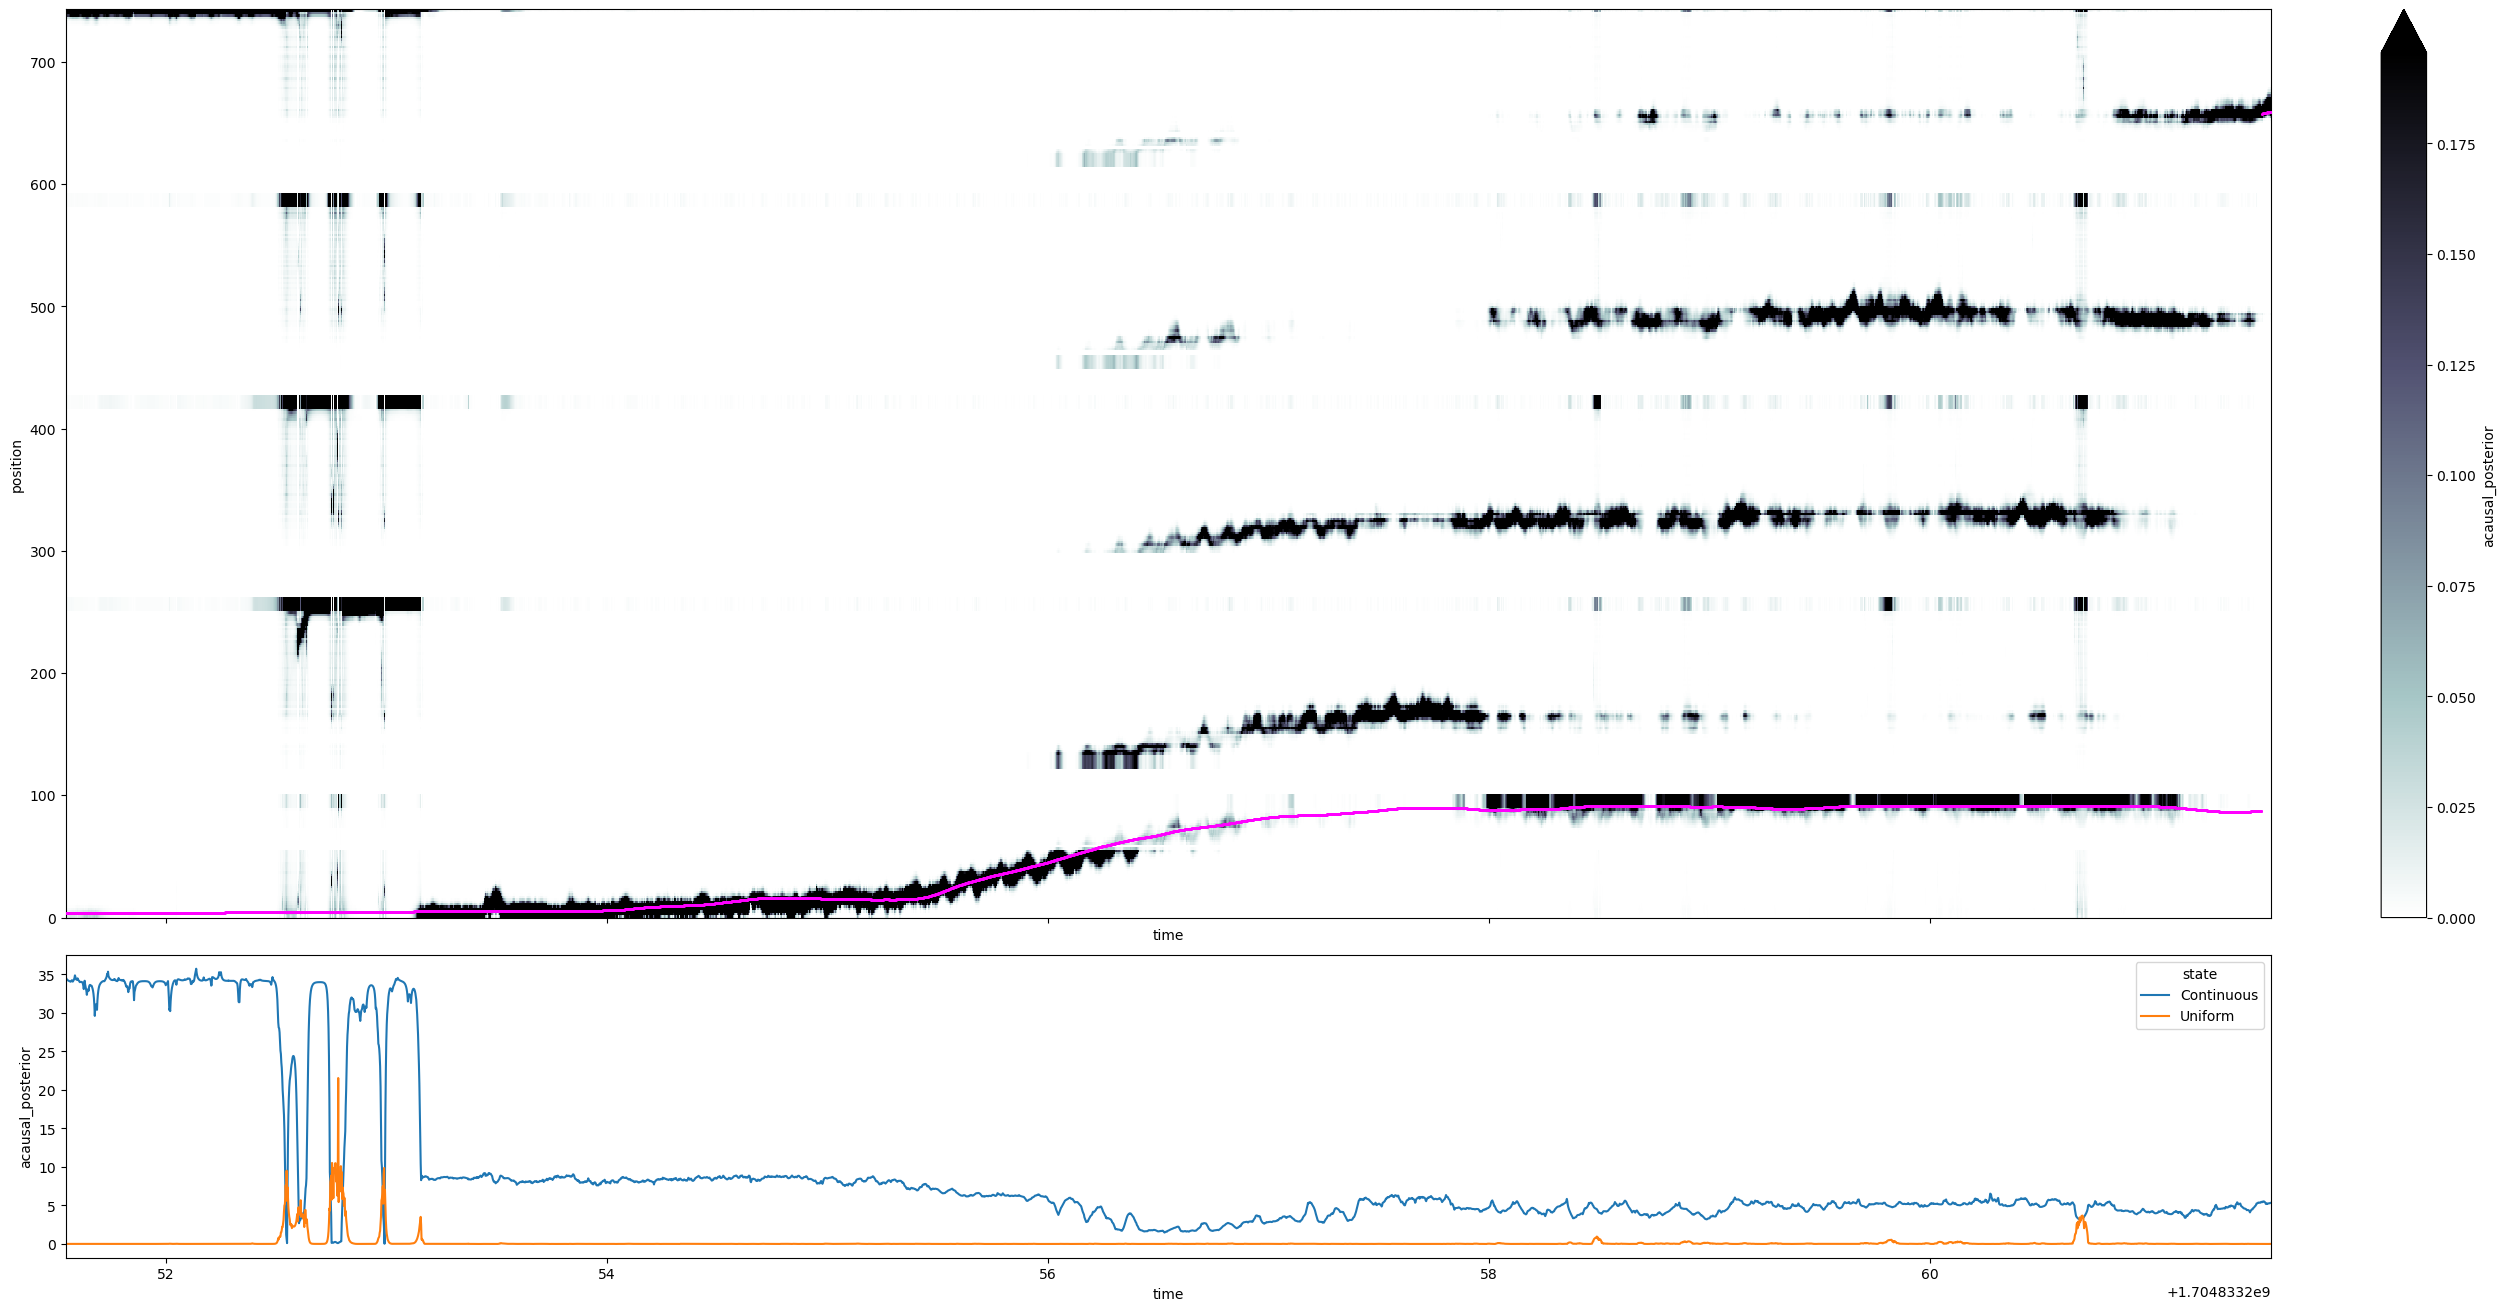

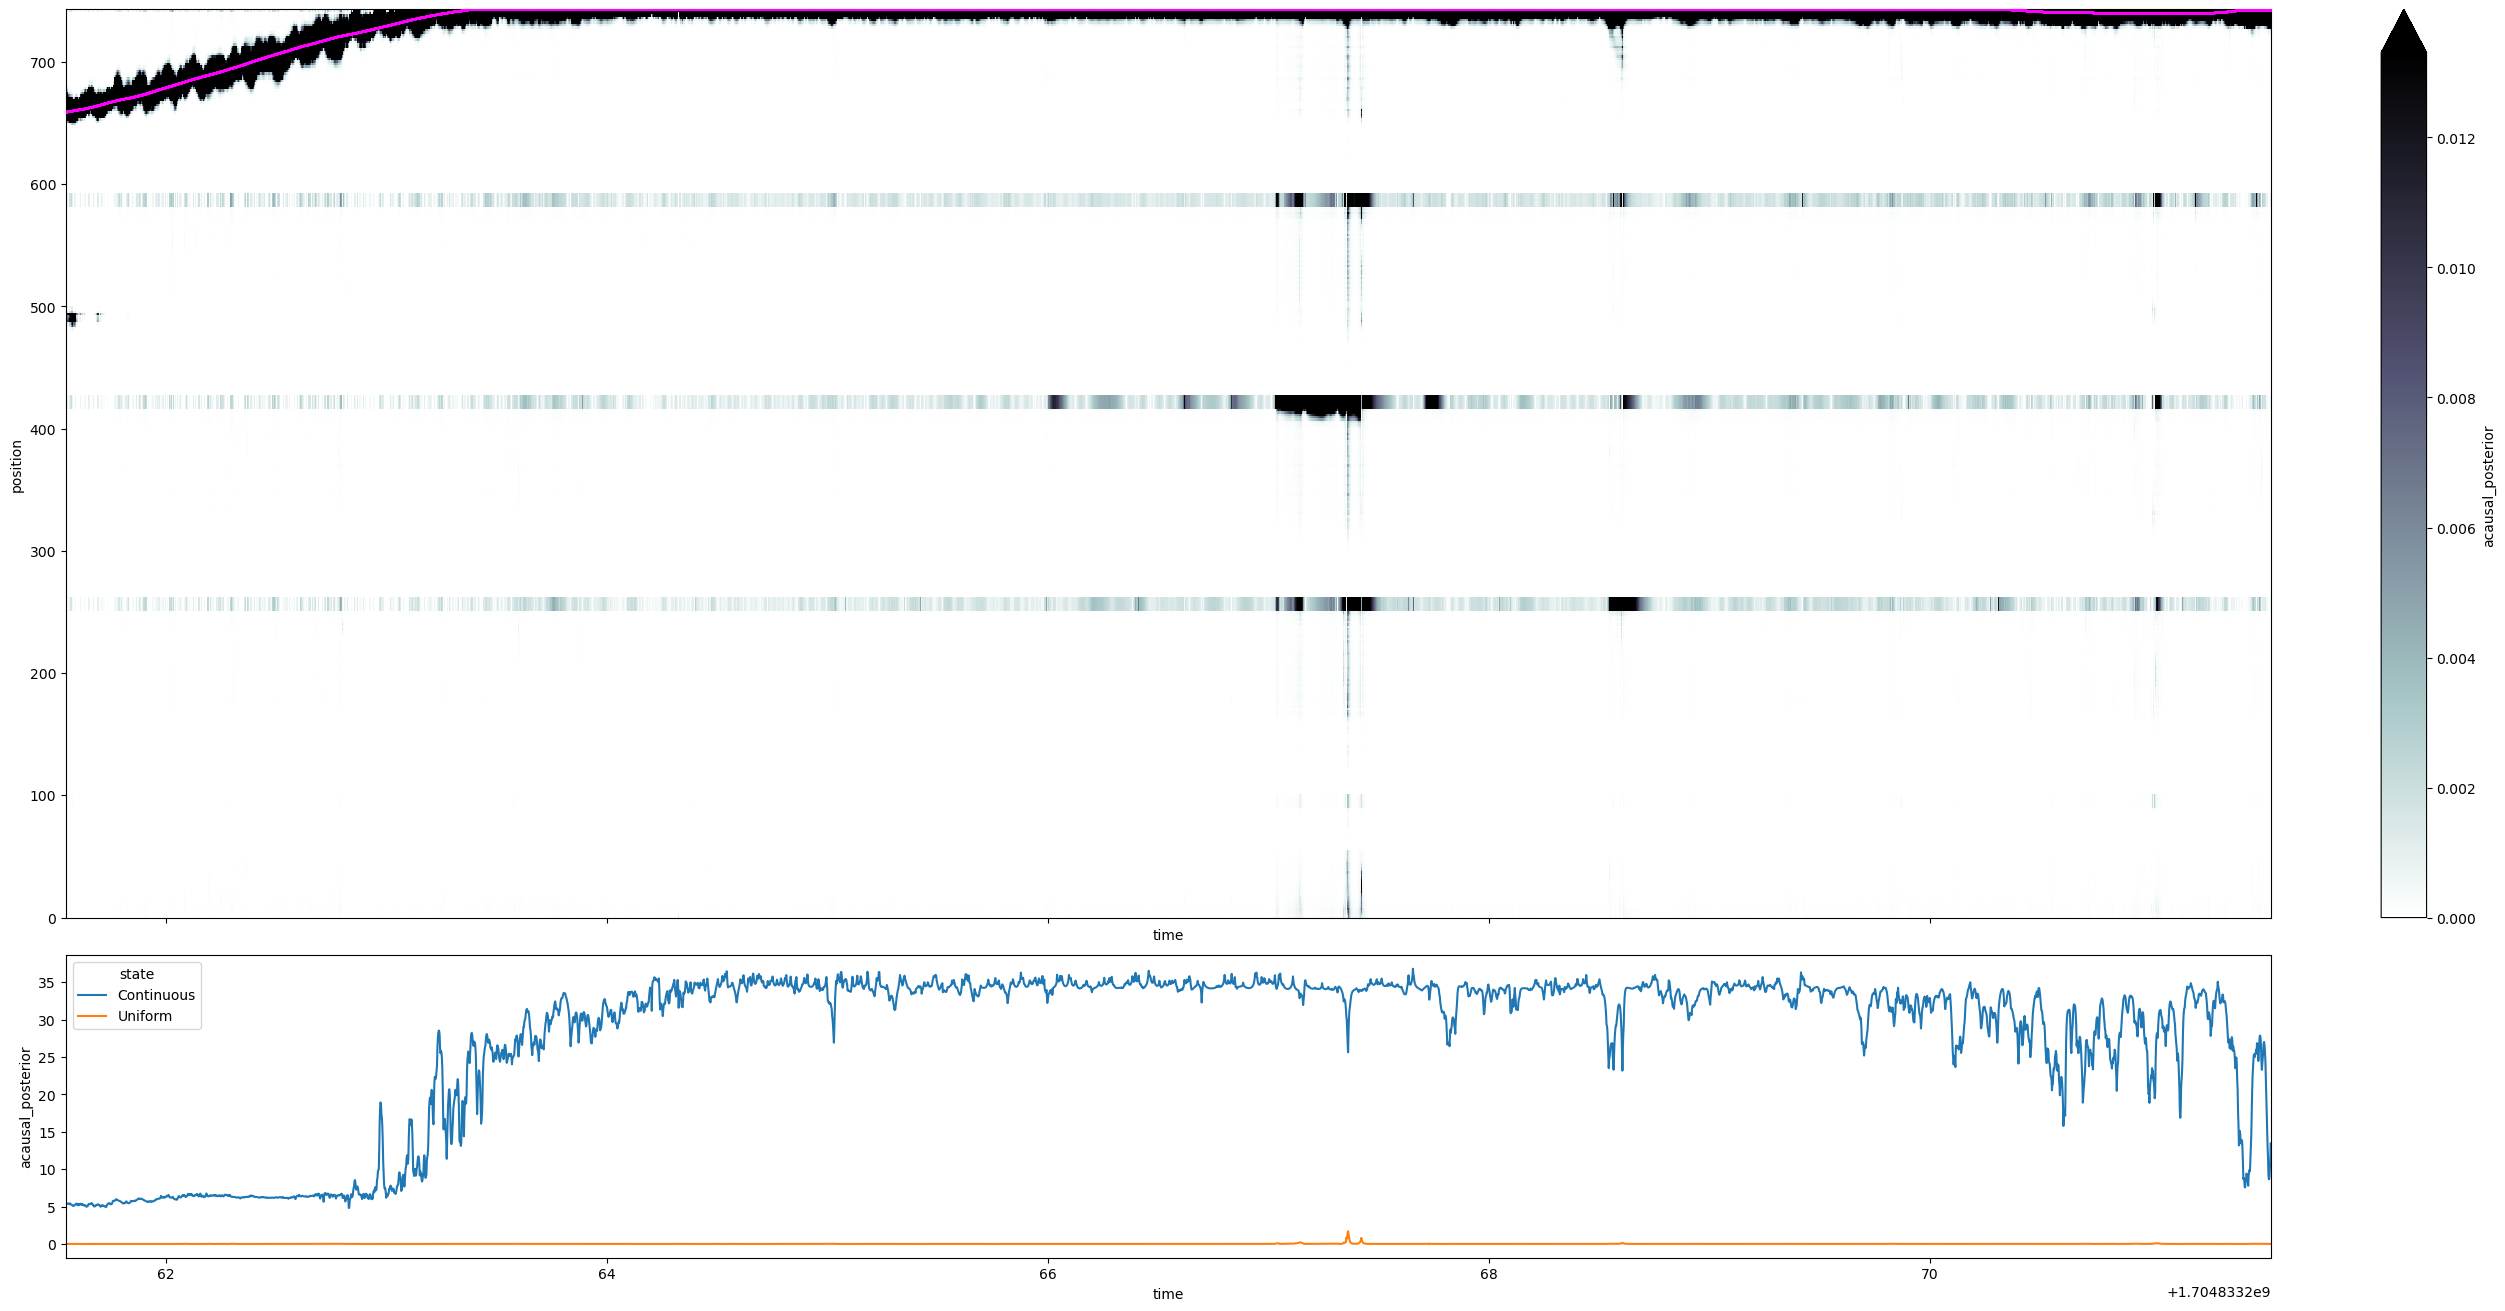

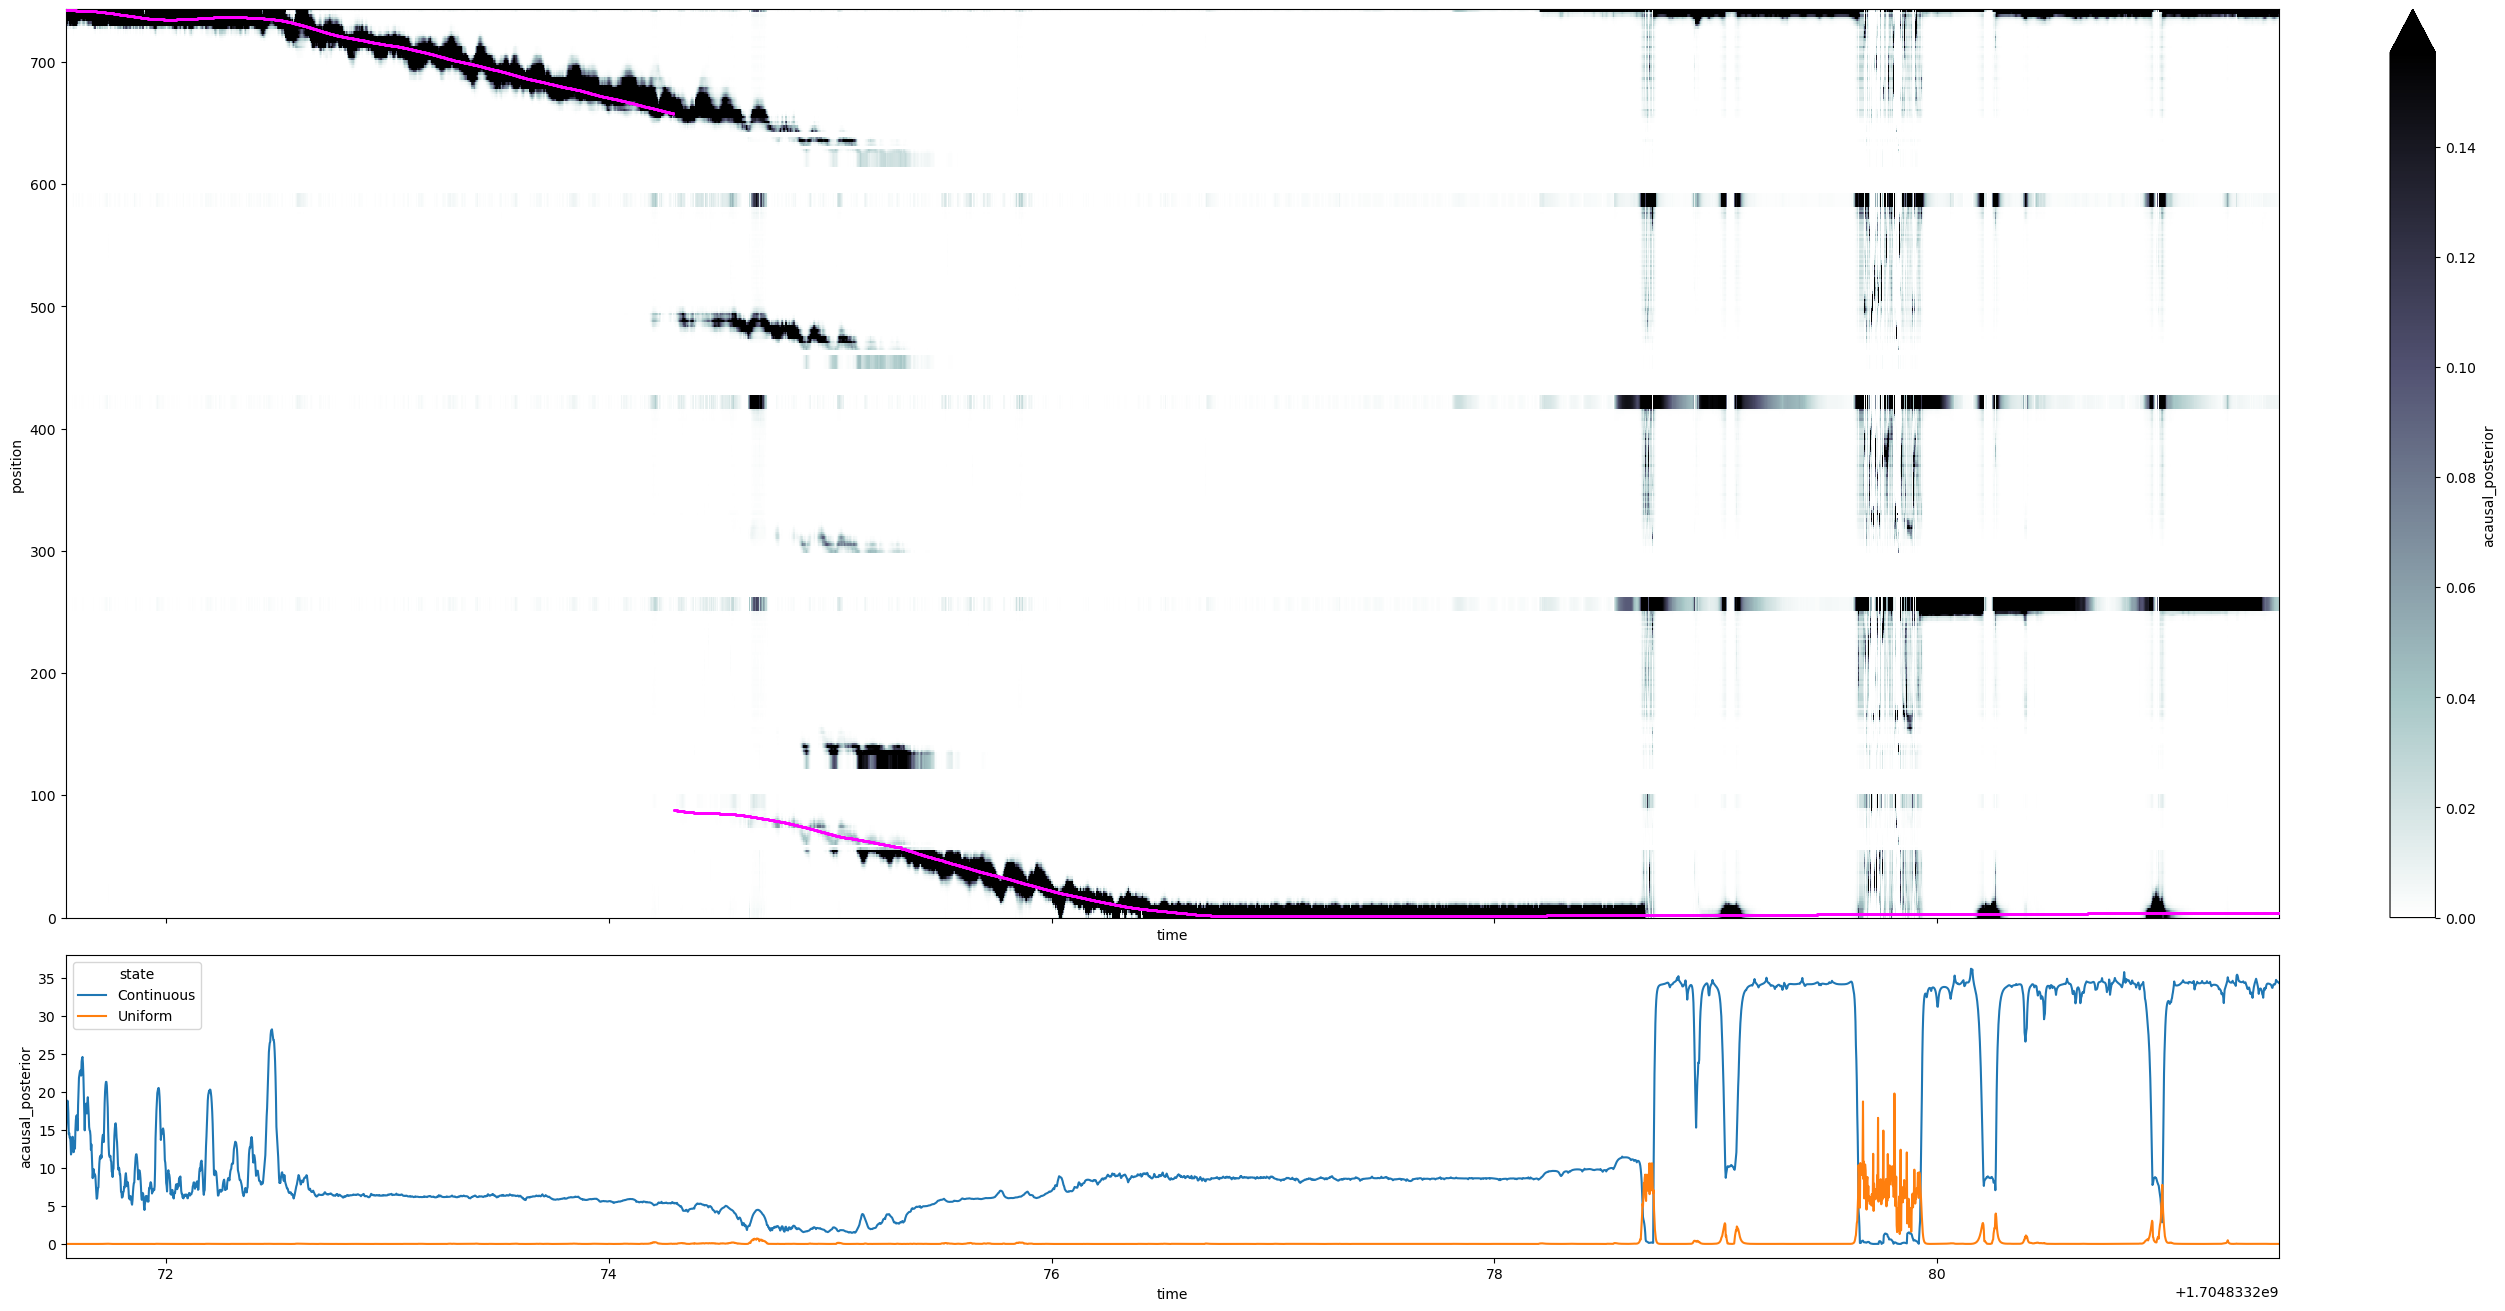

In [104]:
import matplotlib.pyplot as plt
for time_ind in range(frame0, frameLast, 5_000): #range(0, 600_000, 100_000)
    time_slice = slice(time_ind, time_ind + 5_000)

    fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)
    results1D.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position',
                                                                      ax=axes[0], robust=True, cmap='bone_r',rasterized = True)
    axes[0].scatter(position_1d.iloc[time_slice].time,
                    position_1d.iloc[time_slice].linear_position.values,
                    s=1, color='magenta', zorder=10)
 
    results1D.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

## End here.